In [2]:
import pandas as pd
import numpy as np
 
DATA_PATH = "../data/cardekho_dataset.csv"        # notebook lives in notebooks/
OUT_PATH  = "../data/cardekho_cleaned.csv"
 
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()
print("Raw shape:", df.shape)
 
def log(step, before):
    print(f"{step:<55} rows removed: {before - len(df):>4}  -> {len(df)} left")

Raw shape: (15411, 14)


## 1.1 Drop the leftover index column
# `Unnamed: 0` runs from 0 to 19543 but there are only 15,411 rows, so this is an index
# from a bigger original file. It has no meaning for prediction, and it also hides duplicates.

In [3]:
df = df.drop(columns="Unnamed: 0")

## 1.2 Remove exact duplicates

In [4]:
n = len(df)
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
log("Drop exact duplicates", n)

Duplicate rows: 167
Drop exact duplicates                                   rows removed:  167  -> 15244 left


## 1.3 Fix inconsistent labels
# - `ISUZU` vs `Isuzu` (same brand, two spellings)
# - `redi-GO` vs `RediGO` (Datsun)
# - `Dzire LXI/VXI/ZXI` are variants of `Swift Dzire` (Maruti)
# - `Grand` is a truncated `Grand i10` (Hyundai)

In [5]:
df["brand"] = df["brand"].replace({"ISUZU": "Isuzu"})
df["model"] = df["model"].replace({
    "redi-GO": "RediGO",
    "Dzire LXI": "Swift Dzire",
    "Dzire VXI": "Swift Dzire",
    "Dzire ZXI": "Swift Dzire",
    "Grand": "Grand i10",
})
print("Brands:", df["brand"].nunique(), "| Models:", df["model"].nunique())

Brands: 31 | Models: 116



## 1.4 Fix impossible values
# **seats = 0** (2 rows): fill with the most common seat count of that same model.
#
# **Toyota Camry labelled "Electric"** (4 rows): Camry is sold in India as a hybrid, not an EV,
# so these are relabelled `Hybrid`. Otherwise the model would think "Electric" means a Camry.
 

In [6]:
df.loc[df["seats"] == 0, "seats"] = (
    df.groupby("model")["seats"].transform(lambda s: s[s > 0].mode()[0])
)
print("seats == 0 left:", (df["seats"] == 0).sum())
 
df.loc[(df["model"] == "Camry") & (df["fuel_type"] == "Electric"), "fuel_type"] = "Hybrid"
print(df["fuel_type"].value_counts())

seats == 0 left: 0
fuel_type
Petrol    7555
Diesel    7342
CNG        299
LPG         44
Hybrid       4
Name: count, dtype: int64



# ## 1.5 km_driven errors
# - `km_driven > 500,000` is physically unrealistic for these cars (some show 3.8 million km in 5 years).
# - In 22 rows `km_driven` is *exactly equal* to `selling_price` (e.g. Innova: 950,000 km and 950,000 rupees).
#   That is a data-entry mistake (price typed into the km column). Small coincidences like an old Alto at
#   120,000 km and 120,000 rupees are plausible, so only the large ones (>= 300,000) are removed.

In [7]:
n = len(df)
df = df[df["km_driven"] <= 500_000]
log("Drop km_driven > 500,000", n)
 
n = len(df)
same = (df["km_driven"] == df["selling_price"]) & (df["km_driven"] >= 300_000)
df = df[~same].reset_index(drop=True)
log("Drop km_driven == selling_price (large values)", n)

Drop km_driven > 500,000                                rows removed:   12  -> 15232 left
Drop km_driven == selling_price (large values)          rows removed:    2  -> 15230 left


## 1.6 Age and price anomalies
# - `vehicle_age >= 25`: a 29-year-old Maruti Alto (the Alto launched in 2000) and a 25-year-old BMW 3
#   priced at 10 lakh are not believable.
# - A 1-year-old Toyota Camry priced at Rs 3.45 lakh (new price is 30+ lakh) is a price typo.
 

In [8]:
n = len(df)
df = df[df["vehicle_age"] < 25]
log("Drop vehicle_age >= 25", n)
 
n = len(df)
bad_camry = (df["model"] == "Camry") & (df["vehicle_age"] <= 1) & (df["selling_price"] < 1_000_000)
df = df[~bad_camry].reset_index(drop=True)
log("Drop 1-year-old Camry at Rs 3.45 lakh", n)

Drop vehicle_age >= 25                                  rows removed:    2  -> 15228 left
Drop 1-year-old Camry at Rs 3.45 lakh                   rows removed:    1  -> 15227 left


## 1.7 Drop redundant column
# `car_name` is always `brand + " " + model`, so it adds nothing.

In [9]:
df = df.drop(columns="car_name")

## 1.8 Final checks and save


In [10]:
print("Final shape:", df.shape, "| removed", len(df_raw) - len(df), "of", len(df_raw), "rows")
print("Missing values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())
df.describe().T

Final shape: (15227, 12) | removed 184 of 15411 rows
Missing values: 0
Duplicates: 0


,count,mean,std,min,25%,50%,75%,max
vehicle_age,15227.0,6.038813,3.007282,0.0,4.0,6.00,8.0,22.00
km_driven,15227.0,54818.229526,36366.642857,100.0,30000.0,50000.00,70000.0,500000.00
mileage,15227.0,19.699191,4.168795,4.0,17.0,19.67,22.7,33.54
engine,15227.0,1485.890589,520.256111,793.0,1197.0,1248.00,1582.0,6592.00
max_power,15227.0,100.592715,42.915421,38.4,74.0,88.50,117.3,626.00
seats,15227.0,5.326788,0.806511,2.0,5.0,5.00,5.0,9.00
selling_price,15227.0,774684.171209,894938.058714,40000.0,385000.0,559000.00,825000.0,39500000.00


In [11]:
df.to_csv(OUT_PATH, index=False)
print("Saved:", OUT_PATH)

Saved: ../data/cardekho_cleaned.csv


In [12]:
df.head()

,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai,Grand i10,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
 
df = pd.read_csv("../data/cardekho_cleaned.csv")
df["log_price"] = np.log1p(df["selling_price"])
df.shape

(15227, 13)

In [14]:
df["log_price"].describe()

count    15227.000000
mean        13.279298
std          0.686680
min         10.596660
25%         12.861001
50%         13.233907
75%         13.623140
max         17.491811
Name: log_price, dtype: float64

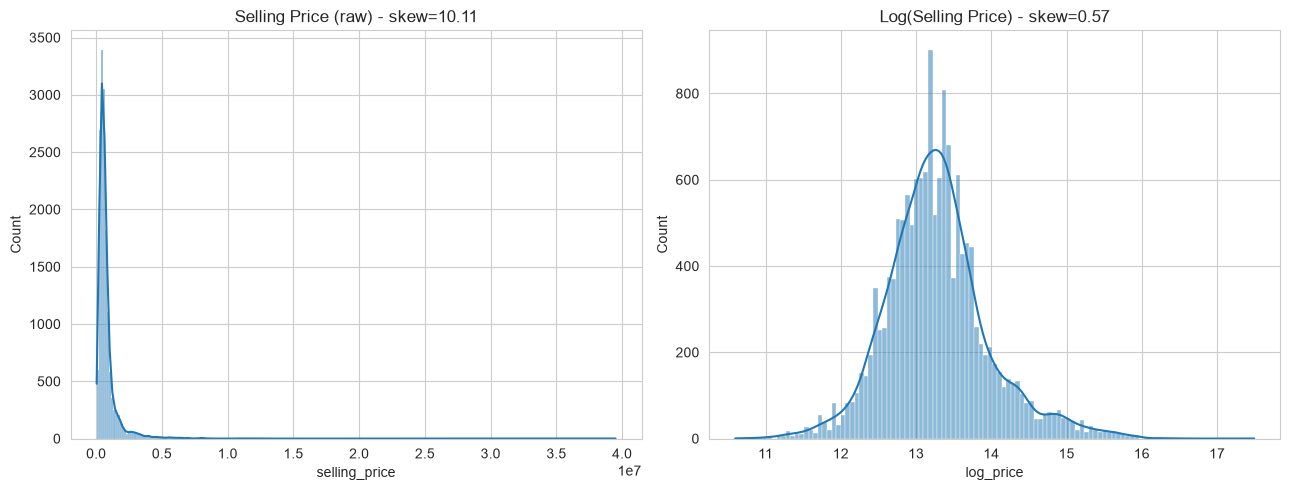

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df["selling_price"], kde=True, ax=axes[0])
axes[0].set_title(f"Selling Price (raw) - skew={df['selling_price'].skew():.2f}")
sns.histplot(df["log_price"], kde=True, ax=axes[1])
axes[1].set_title(f"Log(Selling Price) - skew={df['log_price'].skew():.2f}")
plt.tight_layout()
plt.savefig("../visualizations/price_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

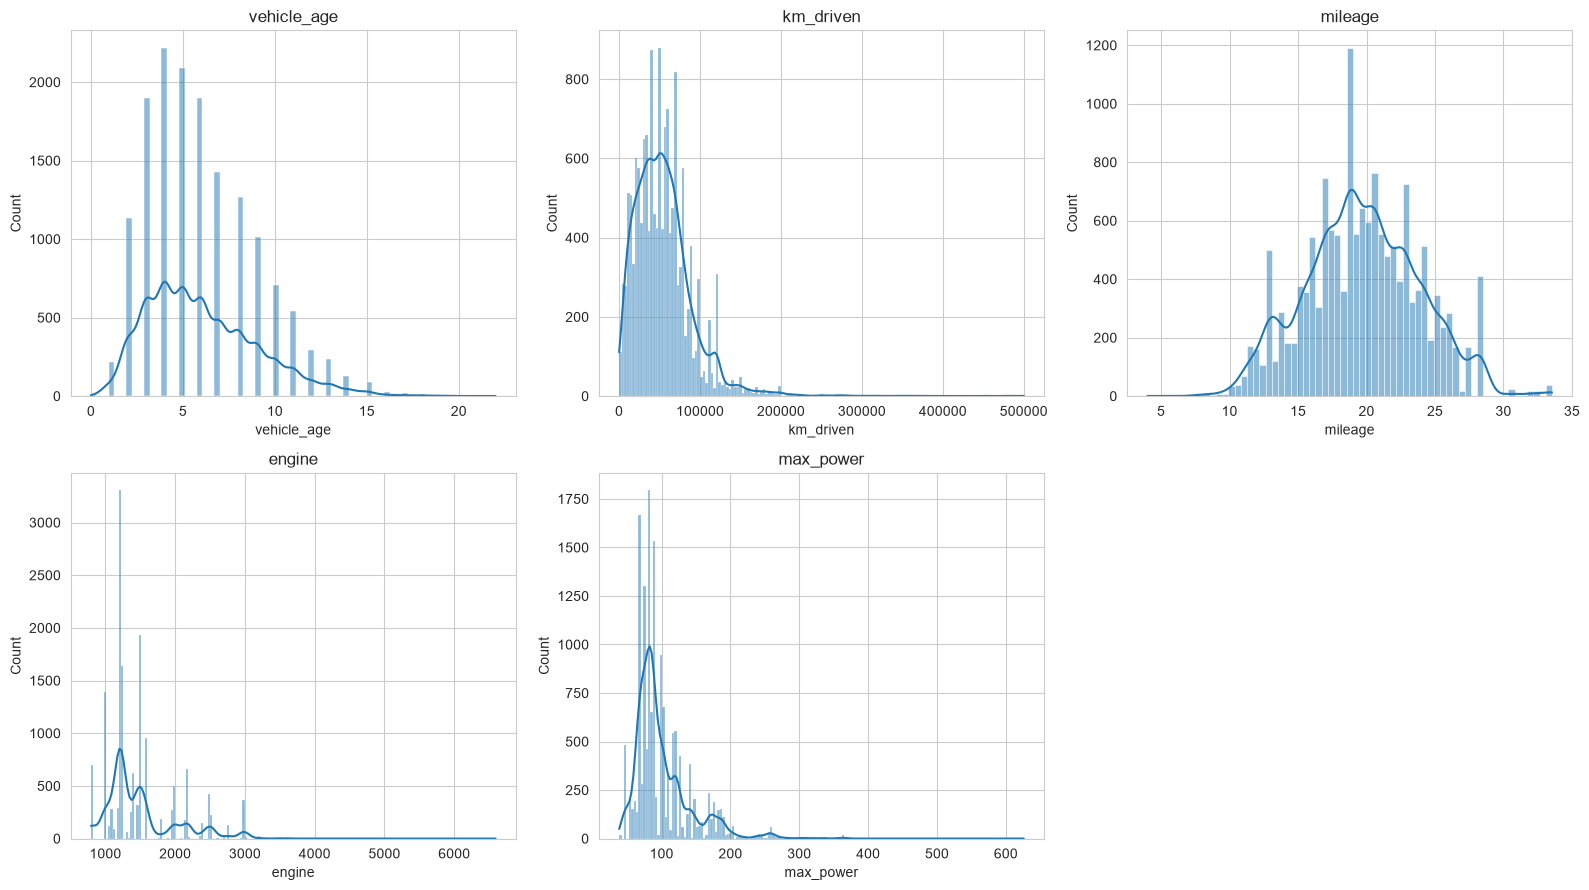

In [16]:
num_cols = ["vehicle_age", "km_driven", "mileage", "engine", "max_power"]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
axes.flat[-1].axis("off")
plt.tight_layout()
plt.savefig("../visualizations/numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

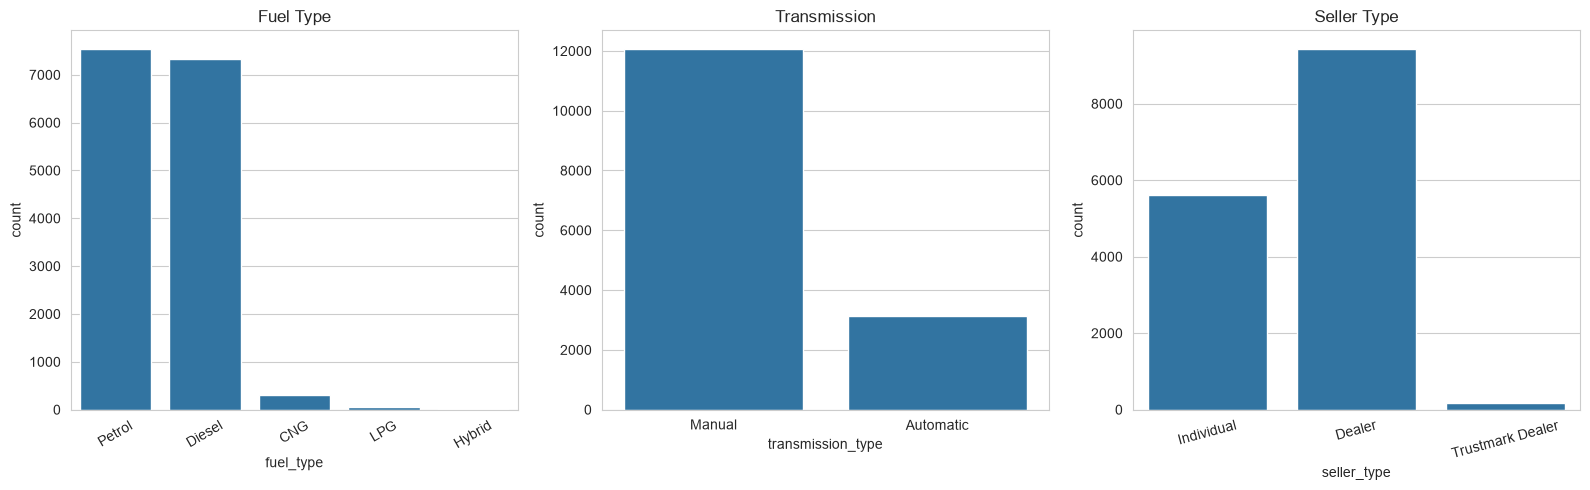

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.countplot(data=df, x="fuel_type", order=df["fuel_type"].value_counts().index, ax=axes[0])
axes[0].set_title("Fuel Type")
axes[0].tick_params(axis="x", rotation=30)
 
sns.countplot(data=df, x="transmission_type", ax=axes[1])
axes[1].set_title("Transmission")
 
sns.countplot(data=df, x="seller_type", ax=axes[2])
axes[2].set_title("Seller Type")
axes[2].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig("../visualizations/categorical_counts.png", dpi=150, bbox_inches="tight")
plt.show()

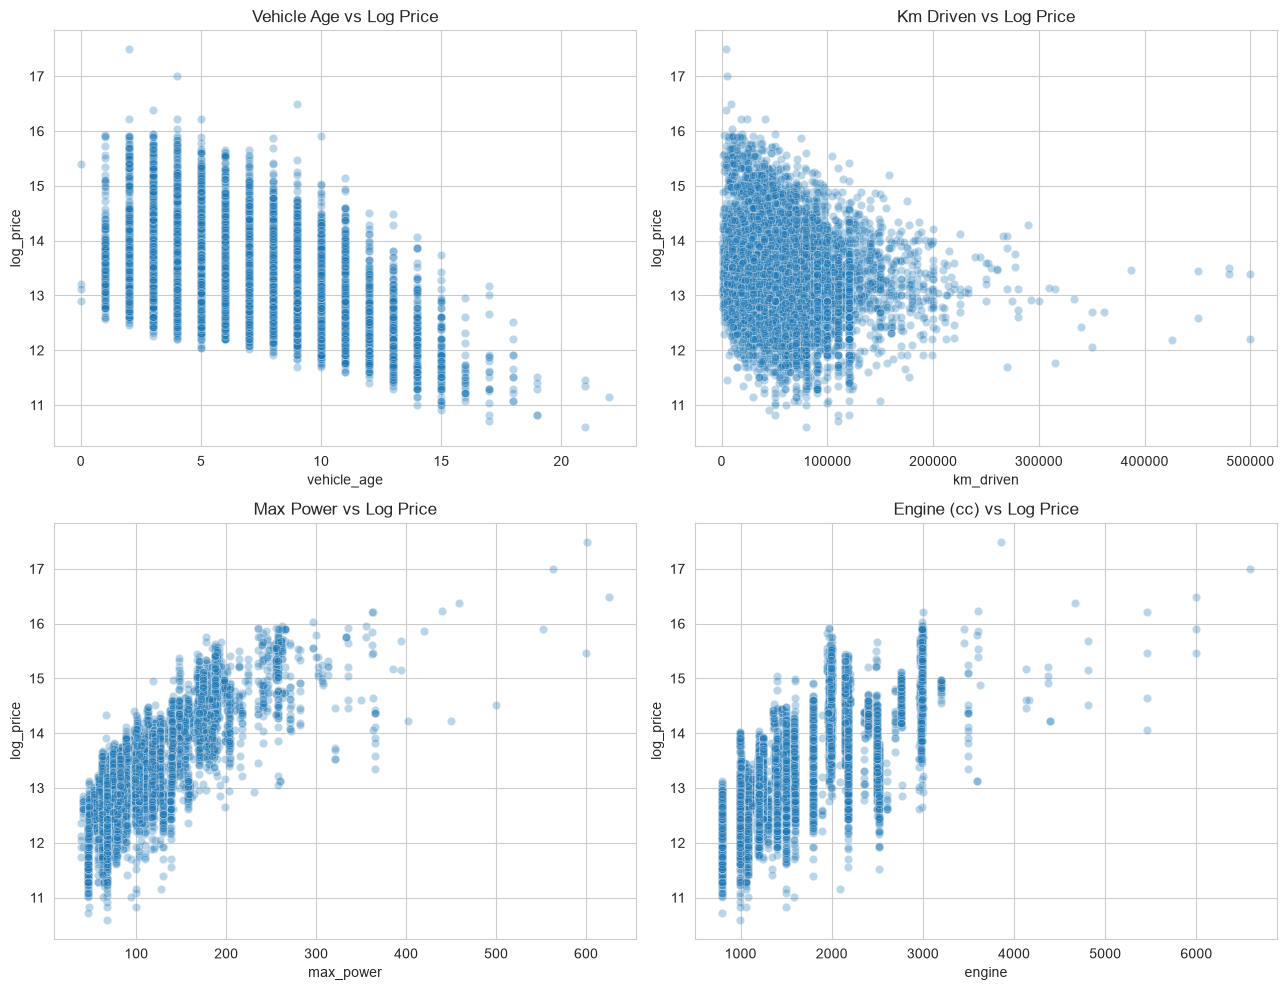

In [18]:

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
sns.scatterplot(data=df, x="vehicle_age", y="log_price", alpha=0.3, ax=axes[0, 0])
axes[0, 0].set_title("Vehicle Age vs Log Price")
 
sns.scatterplot(data=df, x="km_driven", y="log_price", alpha=0.3, ax=axes[0, 1])
axes[0, 1].set_title("Km Driven vs Log Price")
 
sns.scatterplot(data=df, x="max_power", y="log_price", alpha=0.3, ax=axes[1, 0])
axes[1, 0].set_title("Max Power vs Log Price")
 
sns.scatterplot(data=df, x="engine", y="log_price", alpha=0.3, ax=axes[1, 1])
axes[1, 1].set_title("Engine (cc) vs Log Price")
plt.tight_layout()
plt.savefig("../visualizations/numeric_vs_price.png", dpi=150, bbox_inches="tight")
plt.show()
 

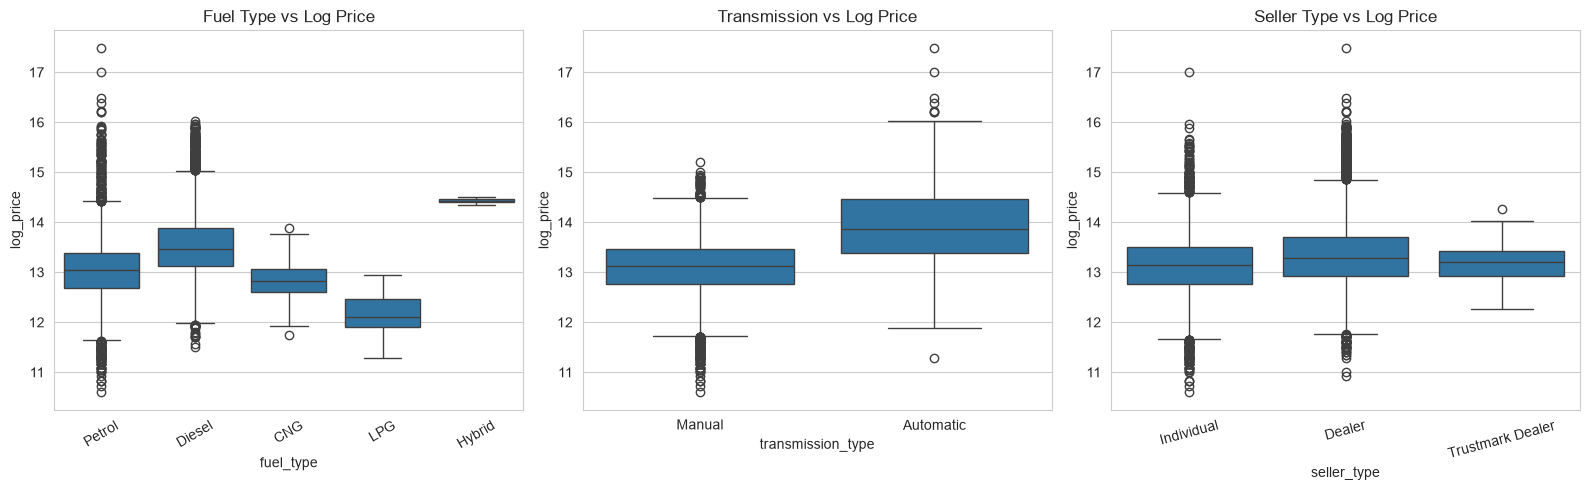

In [19]:

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.boxplot(data=df, x="fuel_type", y="log_price", ax=axes[0])
axes[0].set_title("Fuel Type vs Log Price")
axes[0].tick_params(axis="x", rotation=30)
 
sns.boxplot(data=df, x="transmission_type", y="log_price", ax=axes[1])
axes[1].set_title("Transmission vs Log Price")
 
sns.boxplot(data=df, x="seller_type", y="log_price", ax=axes[2])
axes[2].set_title("Seller Type vs Log Price")
axes[2].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig("../visualizations/categorical_vs_price.png", dpi=150, bbox_inches="tight")
plt.show()
 

In [20]:

brand_stats = (
    df.groupby("brand")
    .agg(median_price=("selling_price", "median"), count=("selling_price", "size"))
    .sort_values("median_price", ascending=False)
)
print(brand_stats.head(10))
print(brand_stats.tail(10))
 

              median_price  count
brand                            
Ferrari         39500000.0      1
Rolls-Royce     24200000.0      1
Bentley          8100000.0      3
Maserati         6100000.0      2
Mercedes-AMG     5100000.0      1
Porsche          5000000.0     21
Lexus            4700000.0      9
Volvo            3750000.0     20
Land Rover       3487500.0     50
Jaguar           2500000.0     58
            median_price  count
brand                          
Force           700000.0      1
Honda           590000.0   1475
Skoda           590000.0    331
Ford            566000.0    774
Tata            550000.0    421
Hyundai         525000.0   2951
Volkswagen      499000.0    612
Maruti          465000.0   4931
Renault         395000.0    526
Datsun          300000.0    170


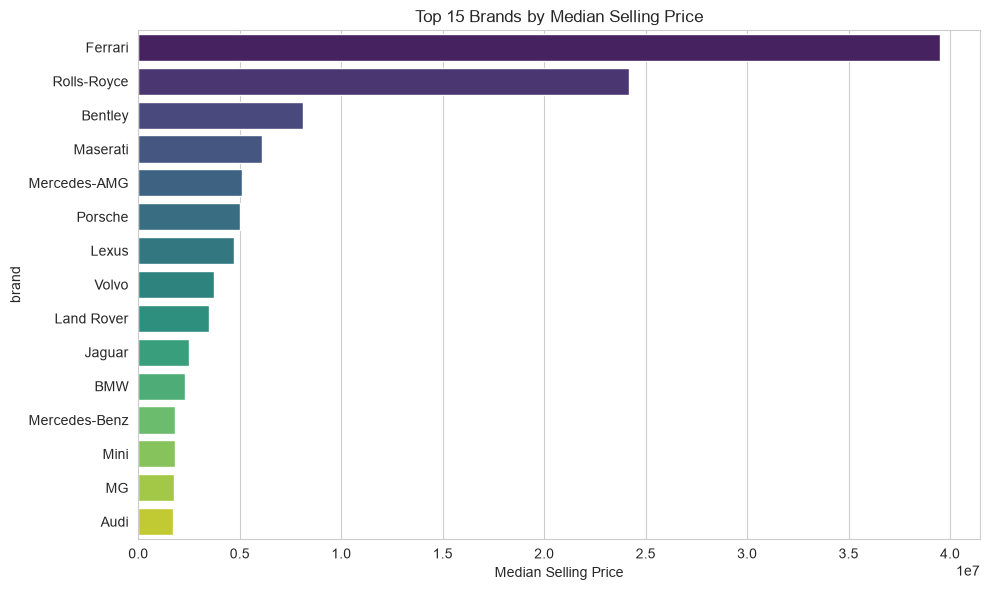

In [21]:
top15 = brand_stats.head(15)
plt.figure(figsize=(10, 6))
sns.barplot(x=top15["median_price"], y=top15.index, hue=top15.index, palette="viridis", legend=False)
plt.title("Top 15 Brands by Median Selling Price")
plt.xlabel("Median Selling Price")
plt.tight_layout()
plt.savefig("../visualizations/top_brands_price.png", dpi=150, bbox_inches="tight")
plt.show()
 

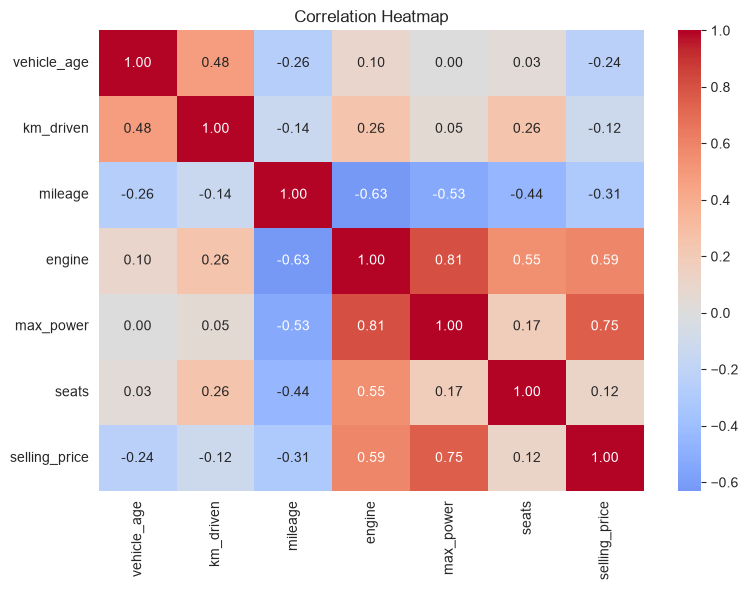

In [22]:

plt.figure(figsize=(8, 6))
corr = df[["vehicle_age", "km_driven", "mileage", "engine", "max_power", "seats", "selling_price"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("../visualizations/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

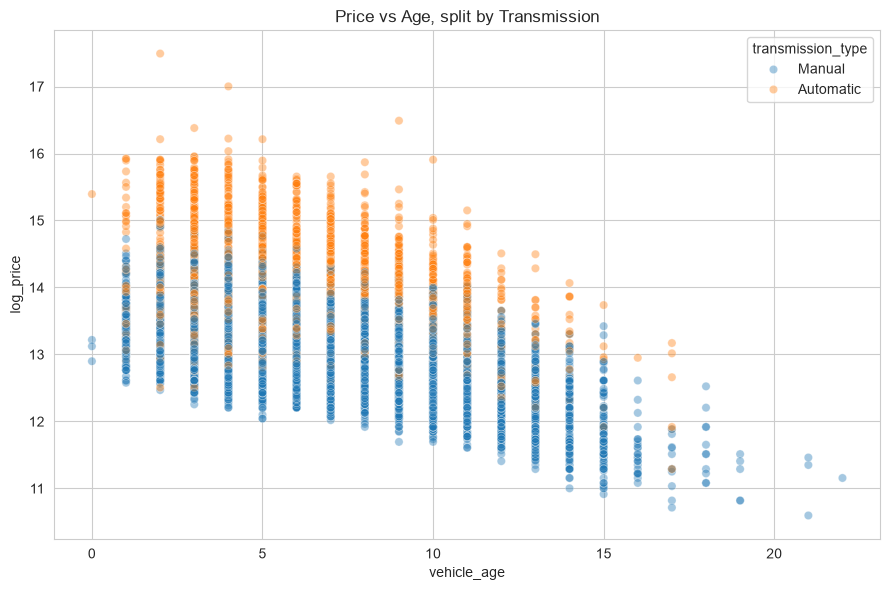

In [23]:

plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="vehicle_age", y="log_price", hue="transmission_type", alpha=0.4)
plt.title("Price vs Age, split by Transmission")
plt.tight_layout()
plt.savefig("../visualizations/age_price_by_transmission.png", dpi=150, bbox_inches="tight")
plt.show()

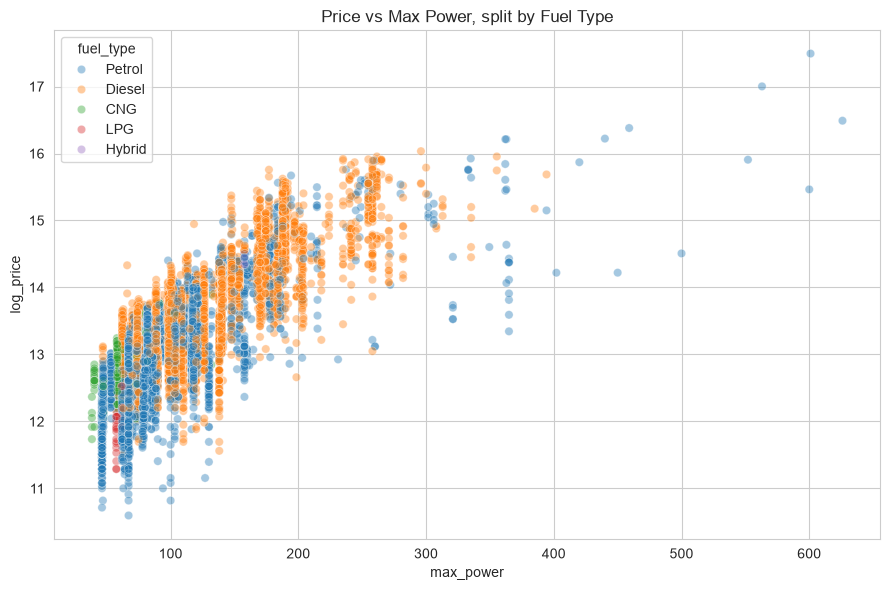

In [24]:

plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="max_power", y="log_price", hue="fuel_type", alpha=0.4)
plt.title("Price vs Max Power, split by Fuel Type")
plt.tight_layout()
plt.savefig("../visualizations/power_price_by_fuel.png", dpi=150, bbox_inches="tight")
plt.show()

## 2.9 Key findings
# - Price is heavily right-skewed; log-transform brings it close to normal.
# - Automatic transmission commands roughly double the median price of manual.
# - Hybrid and Diesel fetch higher median prices than Petrol, CNG, and LPG.
# - max_power is the strongest single numeric predictor of price (corr ~0.75).
# - Price drops sharply in the first ~10 years, then flattens out for older cars.
# - Ultra-luxury brands (Ferrari, Rolls-Royce, Bentley) have 1-3 listings each and
#   behave like outliers rather than a reliable brand trend - worth watching during
#   feature engineering and modeling.